# Junção — a tabela única UF × mês (T-020 / T-021 / T-024)

Objetivo: transformar **cinco tabelas com cinco grãos diferentes** numa só, com chave
`(sigla_uf, ano_mes)`, e explicar o que cada coluna do resultado significa — inclusive o que
significa o vazio dela.

Entrada, toda em `data/interim/`. Repare que **nada aqui compartilha o grão**: cada tabela conta
uma coisa diferente por linha, e o tipo de `ano_mes` muda de fonte para fonte.

| Tabela | Grão de uma linha | Unidade espacial | Fonte |
|---|---|---|---|
| `ipca_alimentos_rm.parquet` | mês × UF × **item** | 16 áreas urbanas | IBGE/SIDRA |
| `clima_estacao_mes.parquet` | **estação** × mês | 701 estações | INMET |
| `safra_uf_mes.parquet` | UF × **produto** × mês | 27 UF | IBGE/LSPA |
| `seca_uf_mes.parquet` | UF × mês | 27 UF | ANA — Monitor de Secas |
| `parquet/macro_br_mes.parquet` | mês | **Brasil** | BCB/SGS |

Saída: [`data/processed/fato_alimentos_uf_mes.parquet`](../data/processed/fato_alimentos_uf_mes.parquet)
— **2.088 linhas × 89 colunas**, 16 UFs × 138 meses (2015-01 a 2026-06).

O desenho está em [analise_juncao_uf_mes.md](../docs/analise_juncao_uf_mes.md); o código que produz
o arquivo está em [24_junta.py](../src/tratamento/24_junta.py). Este notebook mostra **por que** o
código é assim.

## As perguntas que este notebook responde

> *Por que a junção precisa de 200 linhas de código se "é só um merge"?*

Porque dois dos cinco merges falham **em silêncio** se forem escritos do jeito óbvio: um devolve a
tabela inteira vazia sem levantar erro, o outro multiplica as linhas por 11. As duas armadilhas
estão demonstradas na seção 2.

> *A tabela tem colunas com um terço de vazio. Isso é defeito?*

Não. Cada vazio tem um motivo diferente, e um deles — o da seca — muda a conclusão de qualquer
regressão se for lido errado. Seção 6.

In [1]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RAIZ = Path("..").resolve()
sys.path.insert(0, str(RAIZ))

from src.tratamento.chaves import checa_join, padroniza_chaves, valida_chaves

# 24_junta.py começa com número, então não dá para `import` direto. Os notebooks
# 02-05 só liam parquet; este precisa das funções para mostrar a junção acontecendo.
_spec = importlib.util.spec_from_file_location("junta", RAIZ / "src" / "tratamento" / "24_junta.py")
junta = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(junta)

INTERIM = RAIZ / "data" / "interim"
print("módulo carregado:", junta.__name__)

módulo carregado: junta


---
## 0. O bloqueador: o sinal do IPCA

Antes de juntar qualquer coisa era preciso consertar o alvo. O coletor do SIDRA tinha esta linha:

```python
df_clean['valor'].astype(str).str.replace('...', '').str.replace('-', '')   # ERRADO
```

O `-` sozinho é o marcador do SIDRA para "não publicado", e a intenção era removê-lo. Só que
`.str.replace('-', '')` apaga **o sinal de menos de todo valor negativo**: `-0,48` virava `0,48`.
Toda deflação virou inflação. O arquivo antigo tinha **zero valores negativos** em 83.383 linhas e
média de **3,14 %/mês** — 45 % ao ano composto, que não aconteceu.

A correção troca a remoção de caractere por uma troca de marcador, preservando o sinal:

```python
MARCADORES = ['-', '...', '..', 'X', '']
valor_texto = df_clean['valor'].astype(str).str.strip()
df_clean['valor'] = pd.to_numeric(valor_texto.where(~valor_texto.isin(MARCADORES)), errors='coerce')
```

Como o `data/raw/` era byte-idêntico ao `interim/`, não havia bruto intacto guardado: a correção
exigiu **re-executar a coleta** contra a API do SIDRA (168 requisições). A célula abaixo é a prova
de que o dado atual está certo.

In [2]:
ipca_bruto = pd.read_parquet(INTERIM / "ipca_alimentos_rm.parquet")
col_var = next(c for c in ipca_bruto.columns if "Varia" in c)

grupo1 = ipca_bruto[ipca_bruto["item"].str.startswith("1.")][col_var]

pd.DataFrame(
    {
        "antes (bug do sinal)": [83_383, 0, 0.00, 3.141, 94.18],
        "agora (corrigido)": [
            len(ipca_bruto),
            int((ipca_bruto[col_var] < 0).sum()),
            ipca_bruto[col_var].min(),
            ipca_bruto[col_var].mean(),
            ipca_bruto[col_var].max(),
        ],
    },
    index=["linhas", "valores negativos", "mínimo", "média %/mês", "máximo"],
)

,antes (bug do sinal),agora (corrigido)
linhas,"83,383.00","83,383.00"
valores negativos,0.00,"32,696.00"
mínimo,0.00,-56.62
média %/mês,3.14,0.75
máximo,94.18,94.18


32.696 valores negativos onde antes havia zero, e a média cai de 3,14 % para 0,75 %/mês. No grupo
`1.Alimentação e bebidas`, que é o alvo, a média fica em **0,59 %/mês** — a ordem de grandeza certa
para a inflação de alimentos brasileira do período.

> O relatório `data/raw/sidra_ipca/RELATORIO_METADADOS_E_ANALISE_SEMANTICA.md` e o notebook
> `02_exploration_data-raw_sidra_ipca.ipynb` foram escritos contra a versão corrompida e narram
> mínimos que não existiam no arquivo. Precisam ser re-executados.

---
## 1. Diagnóstico: cinco tabelas, cinco grãos

A coluna que importa nesta tabela é a última: **quantas linhas cada fonte tem por `(sigla_uf, ano_mes)`**.
Onde esse número é maior que 1, um merge direto duplica a espinha.

In [3]:
FONTES = {
    "ipca_alimentos_rm":  INTERIM / "ipca_alimentos_rm.parquet",
    "clima_estacao_mes":  INTERIM / "clima_estacao_mes.parquet",
    "safra_uf_mes":       INTERIM / "safra_uf_mes.parquet",
    "seca_uf_mes":        INTERIM / "seca_uf_mes.parquet",
    "macro_br_mes":       INTERIM / "parquet" / "macro_br_mes.parquet",
}

linhas = []
for nome, caminho in FONTES.items():
    df = pd.read_parquet(caminho)
    tem_uf = "sigla_uf" in df.columns
    chave = ["sigla_uf", "ano_mes"] if tem_uf else ["ano_mes"]
    meses = padroniza_chaves(df)["ano_mes"]
    linhas.append({
        "tabela": nome,
        "linhas": len(df),
        "colunas": df.shape[1],
        "tipo de ano_mes": str(df["ano_mes"].dtype),
        "UFs": df["sigla_uf"].nunique() if tem_uf else "— (nacional)",
        "meses": meses.nunique(),
        "de": str(meses.min()),
        "até": str(meses.max()),
        "linhas por UF-mês": round(len(df) / df.groupby(chave).ngroups, 1),
    })

diagnostico = pd.DataFrame(linhas).set_index("tabela")
diagnostico

,linhas,colunas,tipo de ano_mes,UFs,meses,de,até,linhas por UF-mês
tabela,,,,,,,,
ipca_alimentos_rm,83383,8,object,16,241,2006-07,2026-07,25.70
clima_estacao_mes,83814,28,object,27,151,2014-01,2026-07,20.60
safra_uf_mes,44847,11,datetime64[us],27,151,2014-01,2026-07,11.00
seca_uf_mes,3726,14,object,27,138,2015-01,2026-06,1.00
macro_br_mes,151,8,datetime64[us],— (nacional),151,2014-01,2026-07,1.00


Três coisas saltam:

* **`ano_mes` chega em dois tipos incompatíveis** — `object` (a string `"2015-01"`) em ipca, clima e
  seca; `datetime64[us]` em safra e macro. Nenhum merge entre eles funciona, e um deles falha calado.
* **`clima_estacao_mes` tem 20,7 linhas por UF-mês** — são as estações do INMET. Precisa ser agregada.
* **`safra_uf_mes` tem exatamente 11,0** — é o número de produtos. Grade perfeita
  (27 UF × 11 produtos × 151 meses = 44.847), o que garante que o `NaN` da safra nunca é buraco de
  medição, sempre "a UF não planta isso".

Só duas coisas são compartilhadas por todas: **`sigla_uf` e o mês**. Todo o resto tem de ser
reduzido a esse denominador comum.

---
## 2. As duas armadilhas

Esta é a razão de existir de [`chaves.py`](../src/tratamento/chaves.py). As duas células abaixo
escrevem o merge do jeito óbvio e mostram o estrago.

### 2a. O merge que devolve tudo vazio sem levantar erro

O reflexo natural para reconciliar tipos é `astype(str)` dos dois lados. Só que a safra guarda o mês
como *timestamp do dia 1*, então vira `"2015-01-01"`, enquanto o IPCA vira `"2015-01"`. São duas
strings, o pandas aceita o merge, e o resultado é uma coluna 100 % `NaN`.

In [4]:
calendario = junta.monta_calendario()

esquerda = calendario.copy()
esquerda["ano_mes"] = esquerda["ano_mes"].astype(str)          # "2015-01"

safra = pd.read_parquet(INTERIM / "safra_uf_mes.parquet")
safra["ano_mes"] = safra["ano_mes"].astype(str)                # "2015-01-01"  <- silencioso

print(f"esquerda: {esquerda['ano_mes'].iloc[0]!r}   direita: {safra['ano_mes'].iloc[0]!r}")

ruim = esquerda.merge(
    safra[["sigla_uf", "ano_mes", "producao_t"]].drop_duplicates(["sigla_uf", "ano_mes"]),
    on=["sigla_uf", "ano_mes"], how="left",
)
print(f"o merge rodou sem erro. valores não-nulos: {ruim['producao_t'].notna().sum()} de {len(ruim)}")

try:
    checa_join(esquerda, ruim, "teste_desalinhado", ["sigla_uf", "ano_mes"], coluna_teste="producao_t")
except ValueError as erro:
    print(f"\n>>> checa_join disparou:\n{erro}")

esquerda: '2015-01'   direita: '2014-01-01'
o merge rodou sem erro. valores não-nulos: 0 de 3726
  [join] teste_desalinhado      on sigla_uf+ano_mes      3,726 ->  3,726 linhas | match   0.0% (producao_t)

>>> checa_join disparou:
[teste_desalinhado] taxa de match 0 %: as chaves não se encontraram. Confira se ano_mes é Period[M] dos dois lados.


Nenhuma exceção do pandas, nenhum aviso: uma tabela inteira de zeros disfarçada de junção. É por
isso que `checa_join()` roda **depois de cada merge** e trata taxa de match 0 % como erro fatal.

### 2b. O merge que multiplica a espinha por 11

In [5]:
safra_longa = padroniza_chaves(pd.read_parquet(INTERIM / "safra_uf_mes.parquet"))
n_dup = int(safra_longa.duplicated(["sigla_uf", "ano_mes"]).sum())
print(f"safra_uf_mes tem {n_dup:,} duplicatas em (sigla_uf, ano_mes) — uma por produto")

inflado = padroniza_chaves(calendario).merge(
    safra_longa[["sigla_uf", "ano_mes", "producao_t"]], on=["sigla_uf", "ano_mes"], how="left",
)

try:
    checa_join(calendario, inflado, "teste_fanout", ["sigla_uf", "ano_mes"], coluna_teste="producao_t")
except ValueError as erro:
    print(f"\n>>> checa_join disparou:\n{erro}")

safra_uf_mes tem 40,770 duplicatas em (sigla_uf, ano_mes) — uma por produto
  [join] teste_fanout           on sigla_uf+ano_mes      3,726 -> 40,986 linhas | match  79.6% (producao_t)

>>> checa_join disparou:
[teste_fanout] o merge inflou 3,726 -> 40,986 linhas: a tabela da direita duplica ['sigla_uf', 'ano_mes']. Pivote antes de juntar.


Aqui o dano é mais insidioso que o anterior: a taxa de match é **79,6 %**, um número que parece
saudável. Quem olhasse só a taxa não veria nada de errado — e teria 11 cópias de cada mês, uma por
produto, inflando qualquer contagem, média ou regressão por um fator de 11.

### O contrato que fecha as duas portas

[`src/tratamento/chaves.py`](../src/tratamento/chaves.py) ganhou três funções (T-020). O arquivo
também **saiu de `src/tratamento/T-012_T-013/`** para `src/tratamento/`, que é de onde todo o
projeto já o importava — e onde o `parents[2]` dele aponta para a raiz certa.

| Função | O que garante |
|---|---|
| `padroniza_chaves(df)` | `sigla_uf` vira str de 2 maiúsculas, `ano_mes` vira `Period[M]` — aceita str, datetime64 e Period na entrada |
| `valida_chaves(df, nome)` | recusa sigla fora do padrão, `ano_mes` que não seja `Period[M]`, e chave duplicada |
| `checa_join(antes, depois, ...)` | loga linhas antes/depois e taxa de match; **levanta erro** se o nº de linhas mudou ou se o match foi 0 % |

`Period[M]` é o tipo certo porque é o único que **não tem dia**: não existe um "2015-01-01" para
divergir de um "2015-01".

---
## 3. Como cada fonte foi reduzida a UF × mês

### 3a. IPCA — de 40 códigos de item para 17 colunas de variação e 17 de peso

O campo `item` traz o código do IBGE embutido no nome (`"1101002.Arroz"`), então a primeira coisa é
separá-lo. Chavear pelo **código**, não pelo nome: os 40 códigos aparecem sob **42 nomes
diferentes**, porque o IBGE renomeia itens no meio da série — `1111004` era "Leite pasteurizado"
até 2011-12 e virou "Leite longa vida"; `1101053` era "Feijão - macassar" e virou "macáçar" em
2020-01. Agrupar pelo nome quebraria essas séries em duas.

In [6]:
ipca = ipca_bruto.copy()
ipca[["cod_item", "nome_item"]] = ipca["item"].str.split(".", n=1, expand=True)

janela = ipca[(ipca["ano_mes"] >= "2015-01") & (ipca["ano_mes"] <= "2026-06")]
cobertura = janela.groupby("cod_item").size().sort_values(ascending=False)

print(f"{ipca['cod_item'].nunique()} códigos distintos, sob {ipca['item'].nunique()} nomes")
print(f"{(cobertura == 2088).sum()} códigos têm as 2.088 linhas da janela (cobertura máxima)")
print(f"o 18º tem só {cobertura.iloc[17]:,} — cai para 92 % e nunca mais sobe\n")

selecionados = (
    pd.DataFrame(
        [(c, s, n) for c, (s, n) in junta.ITENS_IPCA.items()],
        columns=["cod_item", "slug", "nível na hierarquia"],
    )
    .assign(linhas_na_janela=lambda d: d["cod_item"].map(cobertura))
    .sort_values(["nível na hierarquia", "cod_item"])
    .reset_index(drop=True)
)
selecionados

40 códigos distintos, sob 42 nomes
17 códigos têm as 2.088 linhas da janela (cobertura máxima)
o 18º tem só 1,932 — cai para 92 % e nunca mais sobe



,cod_item,slug,nível na hierarquia,linhas_na_janela
0,1,alimentacao,grupo,2088
1,1102,farinhas,subgrupo,2088
2,1104,acucares,subgrupo,2088
3,1105,hortalicas,subgrupo,2088
4,1107,carnes,subgrupo,2088
5,1109,carnes_industrializadas,subgrupo,2088
6,1110,aves_ovos,subgrupo,2088
7,1111,leites_derivados,subgrupo,2088
8,1101002,arroz,subitem,2088
9,1103003,batata_inglesa,subitem,2088


> ⚠️ **Os 17 misturam três níveis da hierarquia do IBGE de propósito**: o grupo inteiro (`1`), sete
> subgrupos (4 dígitos) e nove subitens (7 dígitos). `1110009` (Frango inteiro) está *dentro de*
> `1110` (Aves e ovos), que está *dentro de* `1` (Alimentação e bebidas).
>
> A consequência prática: **somar as colunas `ipca_peso_*` dupla-conta**. Elas são para ler lado a
> lado — "o frango subiu mais que o grupo?" —, nunca para agregar.

O pivô transforma cada código em duas colunas, e três alvos são derivados:

| Alvo | Como é calculado | Para que serve |
|---|---|---|
| `ipca_var_alimentacao` | variação % no mês do grupo `1` | **alvo principal** |
| `ipca_var_alimentacao_acum12` | produto de `(1 + r)` em 12 meses, por UF | remove a sazonalidade mensal |
| `ipca_var_alimentacao_relativa` | `ipca_var_alimentacao − macro_ipca_mm` | o quanto a comida subiu **além** da inflação geral |

O acumulado em 12 meses é composto, não somado — 12 altas de 1 % dão 12,7 %, não 12 %. E ele é
calculado sobre a **série inteira desde 2006**, antes do recorte: senão os 12 primeiros meses da
janela ficariam vazios por falta de passado.

In [7]:
ipca_largo = junta.prepara_ipca()
print(f"{len(ipca_bruto):,} linhas longas -> {len(ipca_largo):,} linhas largas x {ipca_largo.shape[1]} colunas")
ipca_largo[["sigla_uf", "ano_mes", "ipca_var_alimentacao", "ipca_var_alimentacao_acum12",
            "ipca_var_arroz", "ipca_var_tomate", "ipca_peso_alimentacao"]].tail(4)

83,383 linhas longas -> 3,250 linhas largas x 37 colunas


,sigla_uf,ano_mes,ipca_var_alimentacao,ipca_var_alimentacao_acum12,ipca_var_arroz,ipca_var_tomate,ipca_peso_alimentacao
3246,SP,2026-04,1.24,3.34,3.12,8.34,20.59
3247,SP,2026-05,1.34,4.72,2.13,25.26,20.73
3248,SP,2026-06,-0.09,4.52,-0.33,0.65,20.87
3249,SP,2026-07,-0.41,4.33,-1.32,-26.37,20.86


### 3b. Clima — 701 estações viram uma mediana por UF

Feito em [`21_clima_uf_mes.py`](../src/tratamento/21_clima_uf_mes.py). Duas decisões que não são
óbvias:

* **Mediana, não média.** Uma estação com sensor defeituoso puxa a média e não move a mediana.
* **A chuva agrega por mediana neste passo, não por soma.** A regra "chuva soma" vale para dia → mês
  (já feita em `agrega_mes.py`). Somar o acumulado mensal das ~100 estações do RS daria ~50.000 mm.

E um filtro antes de agregar: **estação-mês com menos de 70 % de dias válidos vira `NaN`** — 22,8 %
das 83.814 linhas. Um mês com 5 dias medidos não é uma medida do mês.

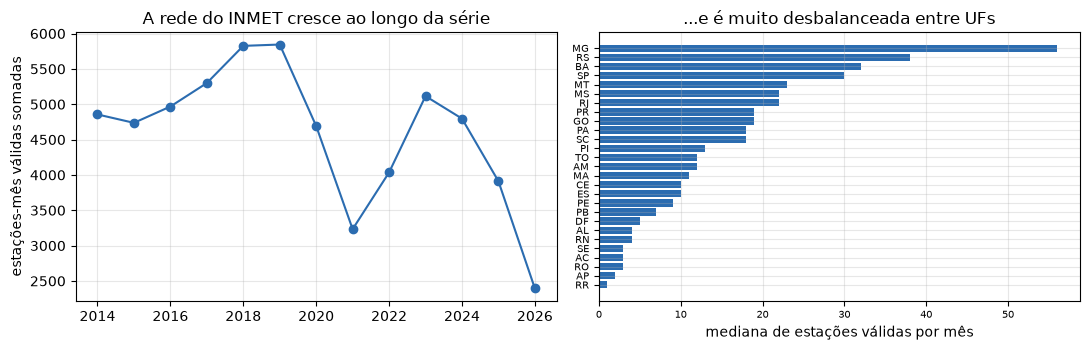

mediana de estações por UF-mês: 11  (mín 0, máx 77)


In [8]:
clima = padroniza_chaves(pd.read_parquet(INTERIM / "clima_uf_mes.parquet"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

rede = clima.groupby(clima["ano_mes"].dt.year)["clima_n_estacoes"].sum()
ax1.plot(rede.index, rede.values, marker="o", color="#2b6cb0")
ax1.set_title("A rede do INMET cresce ao longo da série")
ax1.set_ylabel("estações-mês válidas somadas")

por_uf = clima.groupby("sigla_uf")["clima_n_estacoes"].median().sort_values()
ax2.barh(por_uf.index, por_uf.values, color="#2b6cb0")
ax2.set_title("...e é muito desbalanceada entre UFs")
ax2.set_xlabel("mediana de estações válidas por mês")
ax2.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

print(f"mediana de estações por UF-mês: {clima['clima_n_estacoes'].median():.0f}"
      f"  (mín {clima['clima_n_estacoes'].min()}, máx {clima['clima_n_estacoes'].max()})")

> ⚠️ Os dois gráficos são a razão de `clima_n_estacoes` estar na tabela final apesar de não ser uma
> medida de clima. **Um degrau de nível numa série climática que coincide com um salto de
> `n_estacoes` é artefato da rede, não do clima.** E onde a mediana é tirada de 2 ou 3 estações
> (RR, AP, AC), ela descreve aquelas estações, não a UF.

### 3c. Safra — 11 produtos × 2 medidas = 22 colunas

Das cinco medidas do LSPA, duas entram: `producao_t` (o nível) e `revisao_pct_prod` (a revisão da
estimativa contra o mês anterior da mesma safra). A revisão é **o sinal de choque de oferta** — é
ela que se move quando a lavoura quebra. As outras três (área plantada, área colhida, rendimento)
ficam em `interim/` e podem entrar depois; 55 colunas de saída seriam ruído.

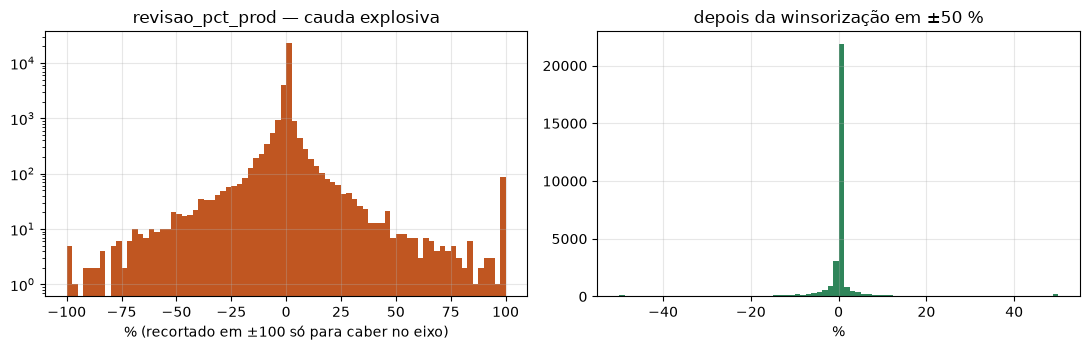

máximo bruto: 15,938,200 %
dentro de ±20 %: 96.6%   |   intactos após a winsorização em ±50 %: 99.1%
NaN em janeiro: 100.0%  (por construção: não há mês anterior dentro da mesma safra)


In [9]:
revisao = safra_longa["revisao_pct_prod"].astype("float64").dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.hist(revisao.clip(-100, 100), bins=80, color="#c05621")
ax1.set_title("revisao_pct_prod — cauda explosiva")
ax1.set_xlabel("% (recortado em ±100 só para caber no eixo)")
ax1.set_yscale("log")

ax2.hist(revisao.clip(-junta.LIMITE_REVISAO, junta.LIMITE_REVISAO), bins=80, color="#2f855a")
ax2.set_title(f"depois da winsorização em ±{junta.LIMITE_REVISAO:.0f} %")
ax2.set_xlabel("%")
plt.tight_layout()
plt.show()

print(f"máximo bruto: {revisao.max():,.0f} %")
print(f"dentro de ±20 %: {revisao.abs().le(20).mean():.1%}   |   "
      f"intactos após a winsorização em ±{junta.LIMITE_REVISAO:.0f} %: "
      f"{revisao.abs().le(junta.LIMITE_REVISAO).mean():.1%}")
print(f"NaN em janeiro: {safra_longa[safra_longa['ano_mes'].dt.month == 1]['revisao_pct_prod'].isna().mean():.1%}"
      "  (por construção: não há mês anterior dentro da mesma safra)")

O máximo bruto passa de 15 milhões % — divisão por uma base minúscula. Sem corte, uma única linha
domina qualquer regressão. A winsorização em ±50 % deixa **99,1 % dos valores intactos** e mexe só
na cauda; o histograma da direita é o mesmo da esquerda, com a escala legível.

> ⚠️ **Cada linha da safra é a estimativa vigente da safra do ANO INTEIRO, não a produção daquele
> mês.** `safra_producao_t_soja` é um estoque/previsão, não um fluxo: somar 12 meses infla ~12×.
>
> ⚠️ Decisão registrada: `safra_producao_t_*` **é preenchida com 0** onde a UF não planta o produto
> (zero tonelada é literalmente verdade, e a grade é perfeita, então nunca é buraco de medição).
> `safra_revisao_pct_*` **fica `NaN`** — ali a revisão é *indefinida*, e 0 significaria "a
> estimativa não mudou", que é outra afirmação.

### 3d. Seca — já está em UF × mês, mas o vazio dela é o mais perigoso da tabela

Só padronizar a chave e prefixar. O problema não é o formato, é a semântica: o Monitor de Secas da
ANA **nasceu no Nordeste em 2014** e foi se expandindo estado a estado.

In [10]:
seca = junta.prepara_seca()

# Só as 16 UFs que sobrevivem ao filtro final — é nelas que a cobertura importa.
UFS_ALVO = sorted(ipca_largo["sigla_uf"].unique())
seca16 = seca[seca["sigla_uf"].isin(UFS_ALVO) & (seca["ano_mes"] <= pd.Period("2026-06", "M"))]

recortes = []
for inicio in ["2015-01", "2018-01", "2020-01", "2021-01", "2024-01"]:
    janela_seca = seca16[seca16["ano_mes"] >= pd.Period(inicio, "M")]
    recortes.append({
        "recorte": f"{inicio} → 2026-06",
        "linhas (16 UF)": len(janela_seca),
        "% monitorado": round(janela_seca["seca_monitorado"].mean() * 100, 1),
    })
pd.DataFrame(recortes).set_index("recorte")

,linhas (16 UF),% monitorado
recorte,,
2015-01 → 2026-06,2208,65.80
2018-01 → 2026-06,1632,77.90
2020-01 → 2026-06,1248,90.50
2021-01 → 2026-06,1056,95.30
2024-01 → 2026-06,480,100.00


> ⚠️ **`seca_monitorado == False` significa "a UF não estava no programa da ANA naquele mês" — não
> "não houve seca".** Preencher esses `NaN` com 0 inventaria ausência de seca onde não houve
> medição, e enviesaria para baixo o efeito estimado da seca justamente nas UFs que entraram tarde.

Entrada no programa: BA/CE/MA/PE/SE em 2015-01 · MG em 2018-11 · ES em 2019-04 · RJ/GO/DF/MS/RS/PR/SP
ao longo de 2020 · AC em 2022-11 · PA em 2023-04.

**Recomendação:** a tabela final guarda a janela cheia, mas qualquer análise que use seca como
regressor deve recortar em **2020-01** (90,5 % de cobertura) ou filtrar por `seca_monitorado`.

### 3e. Macro — de graça, e com uma ressalva

`macro_br_mes` já está pronta e junta só por `ano_mes`. Traz `ipca_mm` (necessário para o alvo
relativo), dólar PTAX, Selic e IGP-M. Eleva o total para **quatro instituições distintas** —
IBGE, INMET, ANA e BCB — com folga sobre o requisito de ≥3 fontes.

> ⚠️ O broadcast é intencional, mas as colunas `macro_*` são **idênticas para todas as UFs no mesmo
> mês**. Elas explicam variação **no tempo**, nunca **entre capitais**.

---
## 4. A junção

A espinha é o **calendário completo** — 27 UFs × 138 meses —, não o IPCA. E todo merge é `LEFT`,
nunca `INNER`. Assim as 11 UFs sem IPCA e os meses sem alvo caem num **único filtro no fim**, onde
a perda é contada, em vez de sumirem aos poucos dentro dos merges.

In [11]:
fato = junta.junta()


[1] Espinha
  [ok] calendario_uf_mes: 3,726 linhas, chave válida


  [ok] safra_uf_mes (longa): 44,847 linhas, chave válida

[2] LEFT JOINs
  [ok] ipca: 3,250 linhas, chave válida
  [join] ipca                   on sigla_uf+ano_mes      3,726 ->  3,726 linhas | match  56.0% (ipca_var_alimentacao)
  [ok] clima: 4,077 linhas, chave válida
  [join] clima                  on sigla_uf+ano_mes      3,726 ->  3,726 linhas | match  96.9% (clima_chuva_mm_mes)
  [ok] safra: 4,077 linhas, chave válida
  [join] safra                  on sigla_uf+ano_mes      3,726 ->  3,726 linhas | match 100.0% (safra_producao_t_milho)
  [ok] seca: 3,726 linhas, chave válida
  [join] seca                   on sigla_uf+ano_mes      3,726 ->  3,726 linhas | match  63.6% (seca_severidade_media)
  [ok] macro: 151 linhas, chave válida
  [join] macro                  on ano_mes               3,726 ->  3,726 linhas | match 100.0% (macro_ipca_mm)

[3] Filtro final
  grade completa       : 3,726 linhas (27 UFs)
  com alvo não-nulo    : 2,088 linhas (16 UFs)


Lendo o log de trás para a frente:

| Fonte | Match na grade de 27 UF | Match na espinha de 16 UF | Por quê |
|---|---|---|---|
| ipca | 56,0 % | **94,6 %** | o alvo só existe nas 16 áreas urbanas; dentro delas, faltam só AC/MA/SE antes de 2018-05 |
| clima | 96,9 % | 99,7 % | quase perfeito; o buraco são UF-meses onde nenhuma estação passou do corte de 70 % |
| safra | 100 % | 100 % | grade perfeita do LSPA |
| seca | 63,6 % | 65,7 % | a expansão do Monitor da ANA, discutida acima |
| macro | 100 % | 100 % | série nacional, existe em todo mês |

**As 3.726 linhas se mantêm nos cinco merges** — é isso que prova que nenhum fan-out aconteceu.

E o filtro final: 3.726 → **2.088**. A conta fecha exatamente:
16 UF × 138 meses = 2.208, menos 3 UFs (AC, MA, SE) × 40 meses sem IPCA = **120**.

---
## 5. Como ficou a tabela

In [12]:
print(f"{len(fato):,} linhas x {fato.shape[1]} colunas")
print(f"chave: (sigla_uf, ano_mes) — duplicatas: {fato.duplicated(['sigla_uf','ano_mes']).sum()}")
print(f"{fato['sigla_uf'].nunique()} UFs x {fato['ano_mes'].nunique()} meses "
      f"({fato['ano_mes'].min()} a {fato['ano_mes'].max()})")
print(f"{fato.memory_usage(deep=True).sum() / 1e6:.1f} MB em memória\n")

familias = (
    fato.columns.to_series()
    .str.extract(r"^(ipca|clima|safra|seca|macro)_")[0]
    .fillna("chave/descritiva")
    .value_counts()
    .rename("colunas")
    .rename_axis("família")
)
print(familias.to_string())

2,088 linhas x 89 colunas
chave: (sigla_uf, ano_mes) — duplicatas: 0
16 UFs x 138 meses (2015-01 a 2026-06)
1.8 MB em memória

família
ipca                36
safra               22
clima               11
seca                 9
chave/descritiva     6
macro                5


In [13]:
fato[["sigla_uf", "ano_mes", "ipca_var_alimentacao", "ipca_var_alimentacao_acum12",
      "clima_chuva_mm_mes", "clima_n_estacoes", "seca_pct_area_S2plus", "seca_monitorado",
      "safra_producao_t_soja", "safra_revisao_pct_milho", "macro_ipca_mm"]].head(6)

,sigla_uf,ano_mes,ipca_var_alimentacao,ipca_var_alimentacao_acum12,clima_chuva_mm_mes,clima_n_estacoes,seca_pct_area_S2plus,seca_monitorado,safra_producao_t_soja,safra_revisao_pct_milho,macro_ipca_mm
0,AC,2018-05,0.62,NaN,166.00,3,NaN,False,"1,404.00",0.00,0.40
1,AC,2018-06,1.15,NaN,29.40,3,NaN,False,"1,404.00",0.00,1.26
2,AC,2018-07,0.27,NaN,32.60,3,NaN,False,"1,410.00",3.88,0.33
3,AC,2018-08,0.32,NaN,60.20,4,NaN,False,"1,410.00",-2.54,-0.09
4,AC,2018-09,-0.29,NaN,97.80,5,NaN,False,"1,410.00",-4.39,0.48
5,AC,2018-10,0.76,NaN,190.80,6,NaN,False,"1,410.00",0.00,0.45


### As 89 colunas, sem corte

`display.max_columns` está em 60 e `max_rows` no padrão, então qualquer `head()` esconde parte da
tabela atrás de `...`. A célula abaixo usa um `option_context` local para mostrar a coisa toda:
primeiro as 89 colunas com tipo, nulos e um exemplo de valor; depois seis linhas da tabela com
todas as colunas lado a lado.


In [ ]:
# Todas as 89 colunas: nome, tipo, nulos e um valor de exemplo — nada truncado.
inventario = pd.DataFrame({
    "familia": fato.columns.to_series()
                   .str.extract(r"^(ipca|clima|safra|seca|macro)_")[0]
                   .fillna("chave").values,
    "dtype": fato.dtypes.astype(str).values,
    "nao_nulos": fato.notna().sum().values,
    "pct_nulos": (fato.isna().mean() * 100).round(1).values,
    "exemplo": [fato[c].dropna().iloc[0] if fato[c].notna().any() else pd.NA
                for c in fato.columns],
}, index=pd.Index(fato.columns, name="coluna"))

with pd.option_context("display.max_rows", None, "display.max_columns", None,
                       "display.width", None, "display.max_colwidth", 40):
    display(inventario)

In [ ]:
# A tabela em si: 6 linhas x 89 colunas, todas visíveis (role na horizontal).
with pd.option_context("display.max_columns", None, "display.width", None,
                       "display.max_colwidth", 18):
    display(fato.head(6))

### O dicionário de variáveis

As 89 colunas estão documentadas em
[`outputs/tabelas/dicionario_variaveis.csv`](../outputs/tabelas/dicionario_variaveis.csv) — nome,
descrição, unidade, fonte, granularidade nativa, % de nulos e a observação sobre o que o vazio
significa. Abaixo, uma amostra de cada família.

In [14]:
DICIONARIO = pd.read_csv(RAIZ / "outputs" / "tabelas" / "dicionario_variaveis.csv")

amostra = DICIONARIO[DICIONARIO["coluna"].isin([
    "sigla_uf", "ano_mes",
    "ipca_var_alimentacao", "ipca_var_alimentacao_relativa", "ipca_peso_carnes",
    "clima_chuva_mm_mes", "clima_n_estacoes",
    "safra_producao_t_soja", "safra_revisao_pct_milho",
    "seca_pct_area_S2plus", "seca_monitorado",
    "macro_ipca_mm",
])]
amostra[["coluna", "unidade", "fonte", "granularidade_nativa", "pct_nulos", "descricao"]].set_index("coluna")

,unidade,fonte,granularidade_nativa,pct_nulos,descricao
coluna,,,,,
sigla_uf,—,IBGE (dim_uf),chave (UF),0.00,"UF, uma das 16 áreas urbanas do IPCA"
ano_mes,mês,IBGE (dim_uf),chave (tempo),0.00,"mês de referência, Period[M]"
ipca_peso_carnes,% do orçamento,IBGE/SIDRA,UF × mês,0.00,peso do subgrupo 1107 na cesta do IPCA da UF — NÃO somar entre colunas
ipca_var_alimentacao,%,IBGE/SIDRA,UF × mês,0.00,variação % no mês do grupo 1 (alimentacao)
clima_chuva_mm_mes,mm,INMET,estação × mês,0.34,acumulado de chuva do mês (mediana entre estações); mediana das estações da UF
clima_n_estacoes,estações,INMET,estação × mês,0.00,"quantas estações da UF mediram chuva no mês — controle do crescimento da rede, não uma..."
safra_producao_t_soja,toneladas,IBGE/LSPA,UF × produto × mês,0.00,"estimativa vigente da safra ANUAL de t soja — é estoque/previsão, não produção do mês;..."
safra_revisao_pct_milho,%,IBGE/LSPA,UF × produto × mês,8.62,revisão % da estimativa de milho vs. o mês anterior da mesma safra (sinal de choque de...
seca_pct_area_S2plus,%,ANA (Monitor de Secas),UF × mês,34.29,área em seca grave ou pior — corte usual de dano


In [ ]:
# O dicionário completo — as 89 linhas de outputs/tabelas/dicionario_variaveis.csv.
with pd.option_context("display.max_rows", None, "display.max_columns", None,
                       "display.width", None, "display.max_colwidth", 70):
    display(
        DICIONARIO[["coluna", "unidade", "fonte", "granularidade_nativa",
                    "pct_nulos", "descricao", "observacao"]].set_index("coluna")
    )

---
## 6. Perfil de nulos — e o que cada vazio quer dizer

Das 89 colunas, **59 não têm um único nulo**. Os vazios se concentram em duas famílias, e as duas
têm motivo documentado.

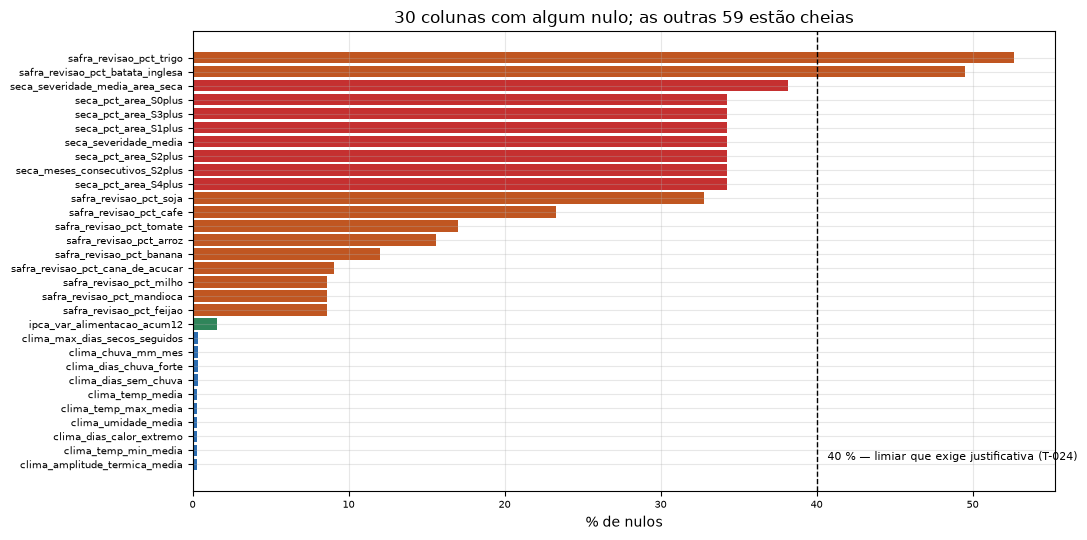

In [15]:
nulos = (fato.isna().mean() * 100).sort_values(ascending=False)
com_nulo = nulos[nulos > 0]

cores = {"seca": "#c53030", "safra": "#c05621", "clima": "#2b6cb0", "ipca": "#2f855a"}
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(
    com_nulo.index[::-1],
    com_nulo.values[::-1],
    color=[cores.get(c.split("_")[0], "#718096") for c in com_nulo.index[::-1]],
)
ax.axvline(40, color="black", ls="--", lw=1)
ax.text(40.7, 0.3, "40 % — limiar que exige justificativa (T-024)", fontsize=8)
ax.set_xlabel("% de nulos")
ax.set_title(f"{len(com_nulo)} colunas com algum nulo; as outras {fato.shape[1] - len(com_nulo)} estão cheias")
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

In [16]:
acima40 = DICIONARIO[DICIONARIO["pct_nulos"] > 40][["coluna", "pct_nulos", "observacao"]]
print(f"colunas acima de 40 % de nulos: {len(acima40)} — todas com justificativa escrita\n")
acima40.set_index("coluna")

colunas acima de 40 % de nulos: 2 — todas com justificativa escrita



,pct_nulos,observacao
coluna,,
safra_revisao_pct_batata_inglesa,49.52,"NaN em safra_revisao_pct_* é indefinição, não falta: janeiro não tem mês anterior dent..."
safra_revisao_pct_trigo,52.68,"NaN em safra_revisao_pct_* é indefinição, não falta: janeiro não tem mês anterior dent..."


Resumo do que significa o vazio, por família:

| Família | % de nulos | O `NaN` significa | Preencher com 0? |
|---|---|---|---|
| `seca_*` | 34-38 % | a UF **não era monitorada** pela ANA naquele mês | **Não** — inventaria ausência de seca onde não houve medição |
| `safra_revisao_pct_*` | 9-53 % | revisão **indefinida**: é janeiro, ou a UF não planta o produto | **Não** — 0 significaria "a estimativa não mudou" |
| `safra_producao_t_*` | 0 % | — | **Já foi**: ausência estrutural virou 0 tonelada, que é literalmente verdade |
| `clima_*` | 0,3 % | nenhuma estação da UF passou do corte de 70 % de dias válidos | Não — mas é raro o bastante para não incomodar |
| `ipca_*_acum12` | 1,6 % | os 12 primeiros meses de AC, MA e SE na amostra | Não — é borda de janela |

As duas colunas acima de 40 % (`safra_revisao_pct_trigo` e `safra_revisao_pct_batata_inglesa`) são
o mesmo fenômeno: poucas UFs da amostra plantam trigo ou batata-inglesa em escala.

---
## 7. Validações de sanidade

Estrutura primeiro, depois história. As checagens estruturais são as do T-024; as históricas testam
se o dado **reconhece eventos que sabemos que aconteceram** — é o que separa uma tabela bem formada
de uma tabela correta.

In [17]:
# A instituição de origem, não o rótulo da fonte: "IBGE/SIDRA" e "IBGE/LSPA" são
# pesquisas diferentes da mesma casa, e o alvo relativo mistura duas ("IBGE/SIDRA + BCB").
INSTITUICOES = {"IBGE": "IBGE", "ANA": "ANA", "BCB": "BCB", "INMET": "INMET"}
instituicoes = {
    INSTITUICOES[parte.split("/")[0].split(" ")[0]]
    for fonte in DICIONARIO["fonte"]
    for parte in fonte.split(" + ")
}

checagens = [
    ("chave (sigla_uf, ano_mes) é única",
     fato.duplicated(["sigla_uf", "ano_mes"]).sum() == 0),
    ("2.088 linhas, 16 UFs, 138 meses",
     (len(fato), fato["sigla_uf"].nunique(), fato["ano_mes"].nunique()) == (2088, 16, 138)),
    ("ano_mes é Period[M], não string",
     isinstance(fato["ano_mes"].dtype, pd.PeriodDtype)),
    ("o alvo tem deflação (bug do sinal corrigido)",
     (fato["ipca_var_alimentacao"] < 0).sum() > 0),
    ("≥ 3 instituições de origem", len(instituicoes) >= 3),
    ("dicionário cobre 100 % das colunas",
     set(DICIONARIO["coluna"]) == set(fato.columns)),
    ("nenhuma coluna > 40 % nula sem justificativa",
     DICIONARIO[(DICIONARIO["pct_nulos"] > 40) & (DICIONARIO["observacao"].isna())].empty),
]

for descricao, ok in checagens:
    print(f"  [{'ok' if ok else 'FALHOU'}] {descricao}")
assert all(ok for _, ok in checagens)

print(f"\n{len(instituicoes)} instituições: {', '.join(sorted(instituicoes))}")
print("pesquisas distintas:", ", ".join(sorted(set(DICIONARIO["fonte"]) - {"IBGE (dim_uf)"})))

  [ok] chave (sigla_uf, ano_mes) é única
  [ok] 2.088 linhas, 16 UFs, 138 meses
  [ok] ano_mes é Period[M], não string
  [ok] o alvo tem deflação (bug do sinal corrigido)
  [ok] ≥ 3 instituições de origem
  [ok] dicionário cobre 100 % das colunas
  [ok] nenhuma coluna > 40 % nula sem justificativa

4 instituições: ANA, BCB, IBGE, INMET
pesquisas distintas: ANA (Monitor de Secas), BCB/SGS, IBGE/LSPA, IBGE/SIDRA, IBGE/SIDRA + BCB, INMET


In [18]:
# Validação histórica 1 — a seca do Ceará em janeiro de 2017, a pior da série no NE.
ce = fato[(fato["sigla_uf"] == "CE") & (fato["ano_mes"] == pd.Period("2017-01", "M"))]
print("CE em 2017-01 (seca histórica do Nordeste):")
print(ce[["seca_pct_area_S2plus", "seca_pct_area_S4plus", "seca_severidade_media"]].to_string(index=False))
assert ce["seca_pct_area_S2plus"].iloc[0] > 99 and ce["seca_severidade_media"].iloc[0] > 4.4

# Validação histórica 2 — o pico de inflação de alimentos de 2020 (câmbio + pandemia).
acum = fato.groupby("ano_mes")["ipca_var_alimentacao_acum12"].median()
print(f"\npico do acumulado 12m: {acum.idxmax()} com {acum.max():.1f}%")
assert pd.Period("2020-06", "M") <= acum.idxmax() <= pd.Period("2021-06", "M")

# Validação histórica 3 — sazonalidade da chuva no Norte/Centro-Oeste.
nco = fato[fato["regiao"].isin(["Norte", "Centro-Oeste"])]
chuva_mes = nco.groupby("mes")["clima_chuva_mm_mes"].median()
print(f"\nchuva mediana Norte/CO — janeiro: {chuva_mes[1]:.0f} mm | agosto: {chuva_mes[8]:.0f} mm")
assert chuva_mes[1] > 5 * chuva_mes[8]
print("\ntodas as validações históricas passaram")

CE em 2017-01 (seca histórica do Nordeste):
 seca_pct_area_S2plus  seca_pct_area_S4plus  seca_severidade_media
               100.00                 63.64                   4.52

pico do acumulado 12m: 2020-11 com 18.1%

chuva mediana Norte/CO — janeiro: 226 mm | agosto: 13 mm

todas as validações históricas passaram


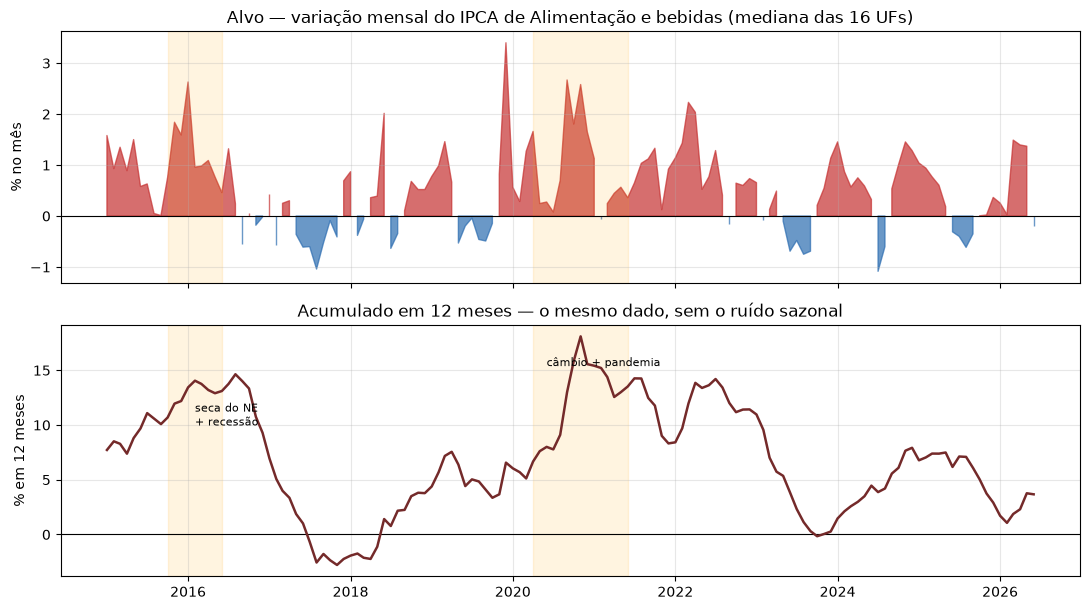

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True)

mensal = fato.groupby("ano_mes")["ipca_var_alimentacao"].median()
eixo = mensal.index.to_timestamp()
ax1.axhline(0, color="black", lw=0.8)
ax1.fill_between(eixo, 0, mensal.values, where=mensal.values >= 0, color="#c53030", alpha=0.7)
ax1.fill_between(eixo, 0, mensal.values, where=mensal.values < 0, color="#2b6cb0", alpha=0.7)
ax1.set_ylabel("% no mês")
ax1.set_title("Alvo — variação mensal do IPCA de Alimentação e bebidas (mediana das 16 UFs)")

acum_ts = fato.groupby("ano_mes")["ipca_var_alimentacao_acum12"].median()
ax2.axhline(0, color="black", lw=0.8)
ax2.plot(acum_ts.index.to_timestamp(), acum_ts.values, color="#742a2a", lw=1.8)
ax2.set_ylabel("% em 12 meses")
ax2.set_title("Acumulado em 12 meses — o mesmo dado, sem o ruído sazonal")

for ax in (ax1, ax2):
    ax.axvspan(pd.Timestamp("2015-10"), pd.Timestamp("2016-06"), color="orange", alpha=0.12)
    ax.axvspan(pd.Timestamp("2020-04"), pd.Timestamp("2021-06"), color="orange", alpha=0.12)
ax2.annotate("seca do NE\n+ recessão", xy=(pd.Timestamp("2016-02"), acum_ts.max() * 0.55), fontsize=8)
ax2.annotate("câmbio + pandemia", xy=(pd.Timestamp("2020-06"), acum_ts.max() * 0.85), fontsize=8)
plt.tight_layout()
plt.show()

Os dois episódios que a literatura registra aparecem sozinhos no dado: a alta de 2016 (seca do
Nordeste somada à recessão) e o pico de **18,1 % em 12 meses em novembro de 2020** (desvalorização
do real e pandemia). O painel de cima mostra por que o acumulado existe — a série mensal alterna
sinal quase todo mês, e é nela que o bug do sinal ficou escondido.

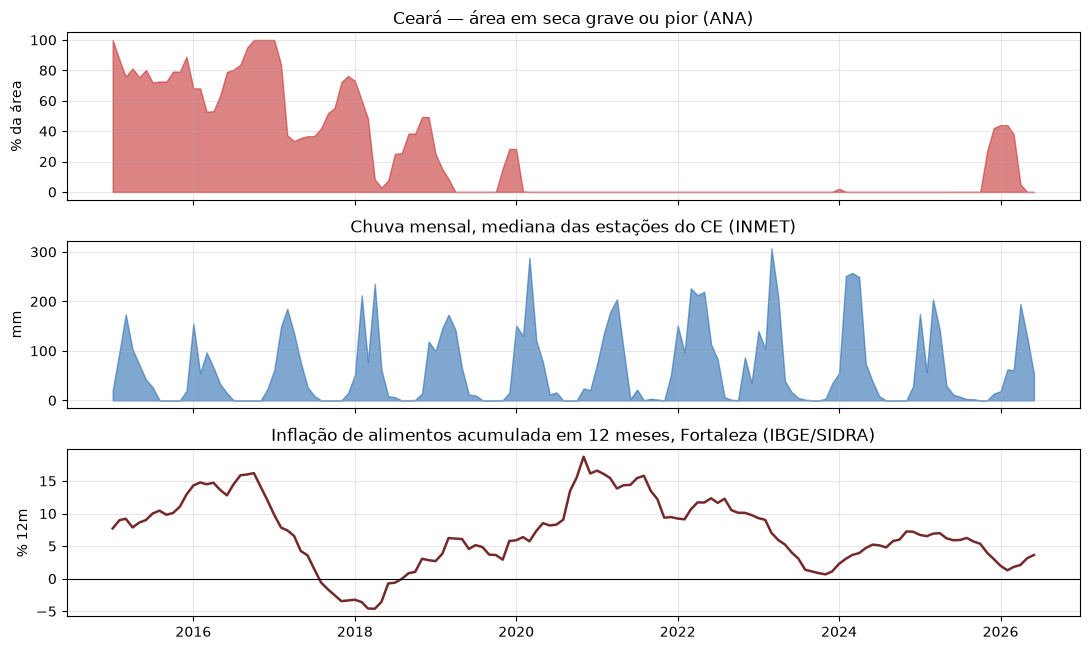

In [20]:
# As três fontes juntas na mesma UF: o teste de que a junção "faz sentido", não só "roda".
ce = fato[(fato["sigla_uf"] == "CE") & (fato["seca_monitorado"] == True)].set_index("ano_mes")
eixo = ce.index.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(11, 6.6), sharex=True)
axes[0].fill_between(eixo, ce["seca_pct_area_S2plus"], color="#c53030", alpha=0.6)
axes[0].set_ylabel("% da área")
axes[0].set_title("Ceará — área em seca grave ou pior (ANA)")

axes[1].fill_between(eixo, ce["clima_chuva_mm_mes"], color="#2b6cb0", alpha=0.6)
axes[1].set_ylabel("mm")
axes[1].set_title("Chuva mensal, mediana das estações do CE (INMET)")

axes[2].plot(eixo, ce["ipca_var_alimentacao_acum12"], color="#742a2a", lw=1.8)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_ylabel("% 12m")
axes[2].set_title("Inflação de alimentos acumulada em 12 meses, Fortaleza (IBGE/SIDRA)")
plt.tight_layout()
plt.show()

Três instituições, três granularidades nativas diferentes, alinhadas no mesmo eixo de tempo e no
mesmo estado. A seca de 2015-2017 cobre quase 100 % do território cearense e coincide com a chuva
baixa; a inflação de alimentos responde com defasagem, o que é exatamente a pergunta que as
features de lag (T-023) existem para medir.

---
## 8. O que dá e o que não dá para fazer com esta tabela

| Dá para | Não dá para |
|---|---|
| Comparar a inflação de um item com a do grupo na mesma UF | Somar `ipca_peso_*` entre colunas (dupla-contagem entre níveis da hierarquia) |
| Regredir o alvo contra clima e safra na série toda | Usar `seca_*` sem filtrar `seca_monitorado` ou recortar em 2020-01 |
| Explicar variação **no tempo** com as colunas `macro_*` | Explicar diferença **entre capitais** com `macro_*` — são idênticas em todas |
| Ler `safra_revisao_pct_*` como choque de oferta | Somar `safra_producao_t_*` ao longo dos meses (é estoque, não fluxo) |
| Comparar clima entre meses da mesma UF | Comparar nível de clima entre UFs sem olhar `clima_n_estacoes` |

---
## O que fica para os próximos tickets

| Ticket | O que falta | O gancho que já existe |
|---|---|---|
| **T-022** — clima ponderado pela produção | agregar estação → UF pesando pela produção agrícola, não por mediana simples | `data/interim/parquet/producao_uf_ano.parquet` já traz `peso_producao_uf`; `data/raw/catalogo_estacoes.csv` tem lat/lon das 701 estações |
| **T-023** — features de lag | chuva e seca defasadas 1-6 meses, médias móveis | `calendario_uf_mes.parquet` é a grade completa: calcular os lags **nele**, antes do filtro do alvo, para não quebrar a borda de AC/MA/SE |
| **T-041** — modelagem | o alvo e os regressores já estão na mesma linha | `ipca_var_alimentacao_relativa` isola o efeito específico de alimentos |
| Re-execução | `02_exploration_data-raw_sidra_ipca.ipynb` e o `RELATORIO_METADADOS` narram a versão com o sinal invertido | o coletor já está corrigido; basta rodar de novo |

Pendência de higiene encontrada no caminho, fora do escopo deste ticket:
`notebooks/03_exploracao_safra_uf.ipynb` lê `data/interim/parquet/safra_uf_mes.parquet`, mas o
arquivo está em `data/interim/safra_uf_mes.parquet`; e `src/coleta/inmet/catalogo.py` declara
escrever em `data/interim/catalogo_estacoes.csv`, enquanto o arquivo está em
`data/raw/catalogo_estacoes.csv`.